# Fase 1: Etiquetado Semiautomático de Logs Web

Este notebook implementa la **fase de etiquetado inicial** de logs de acceso web usando un enfoque **semisupervisado**, combinando:

- **Isolation Forest** (detección de anomalías no supervisada)
- **Heurísticas basadas en firmas** (IoCs simples)

La lógica está inspirada directamente en el paper *Web Traffic Anomaly Detection Using Isolation Forest (2024)*.

> **Nota:** La columna `anomaly` del dataset original se ignora completamente.

In [ ]:
print("dsdfsdf")


dsdfsdf


## 1. Carga del dataset

In [ ]:
import pandas as pd

df = pd.read_csv('../data/target/access_log_master.csv')
df = df.drop(columns=['anomaly'], errors='ignore')
df.head()

,ip_client,timestamp,status,size,user_agent,method,url,protocol,status_category,url__count_sql_words,...,url__count_percentage_symbol,url__count_question_symbol,url__count_hyphen,url__count_equal,url__url_length,url__digit_count,url__letter_count,url__count_special_characters,url__is_encoded,url__unusual_character_ratio
0,47.128.121.63,2025-11-25 00:00:16-05:00,206,500,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/uploads/sites/15/2021/06/b2ap3_lar...,HTTP/2.0,200,0,...,0,0,2,0,74,10,52,12,0,0.094595
1,47.128.121.63,2025-11-25 00:00:16-05:00,200,675,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/plugins/elementor/assets/lib/font-...,HTTP/2.0,200,1,...,0,1,2,1,83,4,63,16,0,0.120482
2,47.128.121.63,2025-11-25 00:00:16-05:00,200,264,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/uploads/sites/15/elementor/css/pos...,HTTP/2.0,200,0,...,0,1,2,1,70,15,43,12,0,0.128571
3,47.128.121.63,2025-11-25 00:00:16-05:00,206,500,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/uploads/sites/15/2021/05/73192906_...,HTTP/2.0,200,0,...,0,0,2,0,96,57,26,13,0,0.072917
4,47.128.121.63,2025-11-25 00:00:16-05:00,206,500,Mozilla/5.0 (Linux; Android 5.0) AppleWebKit/5...,GET,/wp-content/uploads/sites/15/2021/07/PNG-image...,HTTP/2.0,200,0,...,0,0,4,0,61,16,33,12,0,0.114754


## 2. Limpieza básica y selección de columnas

In [5]:
df = df.dropna()

categorical_cols = ['method', 'protocol', 'status_category']
numeric_cols = ['size', 'url__url_length', 'url__digit_count', 'url__count_special_characters', 'url__unusual_character_ratio']

ioc_cols = [
    c for c in df.columns
    if c.startswith('url__count_') and c not in numeric_cols
]

features = categorical_cols + numeric_cols + ioc_cols
df_model = df[features]

df_model.head()

,method,protocol,status_category,size,url__url_length,url__digit_count,url__count_special_characters,url__unusual_character_ratio,url__count_sql_words,url__count_xss_words,...,url__count_malware_words,url__count_danger_characters,url__count_obfuscation_code_words,url__count_dir_words,url__count_dot,url__count_http,url__count_percentage_symbol,url__count_question_symbol,url__count_hyphen,url__count_equal
0,GET,HTTP/2.0,200,500,74,10,12,0.094595,0,0,...,0,0,0,0,1,0,0,0,2,0
1,GET,HTTP/2.0,200,675,83,4,16,0.120482,1,0,...,0,0,0,1,4,0,0,1,2,1
2,GET,HTTP/2.0,200,264,70,15,12,0.128571,0,0,...,0,0,0,0,1,0,0,1,2,1
3,GET,HTTP/2.0,200,500,96,57,13,0.072917,0,0,...,0,0,0,0,1,0,0,0,2,0
4,GET,HTTP/2.0,200,500,61,16,12,0.114754,0,0,...,0,0,0,0,1,0,0,0,4,0


## 3. Pipeline de preprocesamiento (One-Hot + Scaling)

In [6]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols + ioc_cols)
    ]
)

X = preprocessor.fit_transform(df_model)

## 4. Entrenamiento de Isolation Forest

In [20]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    max_samples=0.25,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",0.25
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.03
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


## 5. Detección de anomalías

In [21]:
df['if_prediction'] = iso_forest.predict(X)  # -1 anomalía, 1 normal
df['if_score'] = iso_forest.decision_function(X)

df[['if_prediction', 'if_score']].head()

,if_prediction,if_score
0,1,0.084235
1,1,0.058826
2,1,0.080406
3,1,0.071534
4,1,0.083116


In [22]:
anomalies = df[df['if_prediction'] == -1]
anomalies.shape




(29639, 32)

In [ ]:
top_anomalies = (
    df[df['if_prediction'] == -1]
    .sort_values('if_score')
    .head(20)
)

top_anomalies

,ip_client,timestamp,status,size,user_agent,method,url,protocol,status_category,url__count_sql_words,...,url__count_hyphen,url__count_equal,url__url_length,url__digit_count,url__letter_count,url__count_special_characters,url__is_encoded,url__unusual_character_ratio,if_prediction,if_score
553314,64.225.115.99,2025-11-22 23:07:58-05:00,302,5,Mozilla/5.0 (Kubuntu; Linux x86_64; rv:122.0) ...,GET,/index.action?redirect%3A%24%7B%23context%5B%2...,HTTP/1.1,300,2,...,1,0,651,106,422,123,1,0.149002,-1,-0.338860
553315,64.225.115.99,2025-11-22 23:07:58-05:00,302,5,Mozilla/5.0 (Fedora; Linux i686; rv:123.0) Gec...,GET,/index.action?redirectAction%3A%24%7B%23contex...,HTTP/1.1,300,2,...,1,0,657,106,428,123,1,0.147641,-1,-0.338754
553312,64.225.115.99,2025-11-22 23:07:58-05:00,302,5,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,GET,/index.action?action%3A%24%7B%23context%5B%22x...,HTTP/1.1,300,2,...,1,0,649,106,420,123,1,0.149461,-1,-0.334949
810576,209.35.184.67,2025-11-20 14:44:35-05:00,200,7925,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,GET,/theme/yui_combo.php?3.17.2/dd-gestures/dd-ges...,HTTP/2.0,200,0,...,26,0,623,96,425,102,0,0.086677,-1,-0.334083
116608,152.206.172.100,2025-11-24 04:20:35-05:00,200,7925,Mozilla/5.0 (Linux; Android 8.0.0; moto e5 pla...,GET,/theme/yui_combo.php?3.17.2/dd-gestures/dd-ges...,HTTP/2.0,200,0,...,26,0,623,96,425,102,0,0.086677,-1,-0.334083
148426,200.55.156.13,2025-11-24 08:49:35-05:00,200,7925,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,GET,/theme/yui_combo.php?3.17.2/dd-gestures/dd-ges...,HTTP/2.0,200,0,...,26,0,623,96,425,102,0,0.086677,-1,-0.334083
364016,152.206.236.213,2025-11-23 14:47:30-05:00,200,7925,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,GET,/theme/yui_combo.php?3.17.2/dd-gestures/dd-ges...,HTTP/2.0,200,0,...,26,0,623,96,425,102,0,0.086677,-1,-0.334083
872828,152.206.120.191,2025-11-20 22:03:39-05:00,200,7925,Mozilla/5.0 (Linux; Android 8.0.0; moto e5 pla...,GET,/theme/yui_combo.php?3.17.2/dd-gestures/dd-ges...,HTTP/2.0,200,0,...,26,0,623,96,425,102,0,0.086677,-1,-0.334083
621539,200.14.51.145,2025-11-21 10:36:04-05:00,200,7619,Mozilla/5.0 (Windows NT 6.1; rv:109.0) Gecko/2...,GET,/theme/yui_combo.php?m/1670440364/core/widget/...,HTTP/2.0,200,0,...,23,0,585,92,400,93,0,0.087179,-1,-0.331443
170605,152.169.223.50,2025-11-24 11:04:34-05:00,200,7619,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,GET,/theme/yui_combo.php?m/1670440364/core/widget/...,HTTP/2.0,200,0,...,23,0,585,92,400,93,0,0.087179,-1,-0.331443


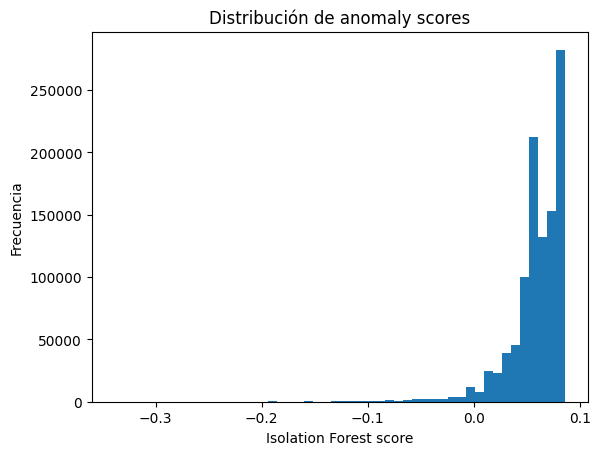

In [15]:
import matplotlib.pyplot as plt

plt.hist(df['if_score'], bins=50)
plt.xlabel('Isolation Forest score')
plt.ylabel('Frecuencia')
plt.title('Distribución de anomaly scores')
plt.show()


In [14]:
df[df['if_prediction'] == -1].to_csv(
    'anomalies_for_review.csv',
    index=False
)


## 6. Etiquetado basado en firmas (IoC heurístico)

In [ ]:
df['signature_flag'] = (df[ioc_cols].sum(axis=1) > 0).astype(int)

df[['signature_flag']].value_counts()

## 7. Etiqueta final semiautomática

Regla:
- **Ataque (1)**: Isolation Forest = anomalía **O** firma activada
- **Normal (0)**: caso contrario


In [ ]:
df['attack_label'] = ((df['if_prediction'] == -1) | (df['signature_flag'] == 1)).astype(int)

df['attack_label'].value_counts()

## 8. Dataset etiquetado resultante

In [ ]:
df.to_csv('labeled_web_logs.csv', index=False)
df.head()

## Resultado

El archivo `labeled_web_logs.csv` puede utilizarse como **dataset inicial etiquetado** para entrenar un modelo supervisado (Random Forest, XGBoost, LSTM, etc.).

Se recomienda:
- Revisar manualmente una muestra de `attack_label = 1`
- Ajustar `contamination`
- Refinar firmas según contexto real